Import libraries

In [219]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

Load dataset ([IMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset))

In [220]:
df = pd.read_csv("movie_metadata.csv")

df.head()



,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [221]:
print("Dataset Shape:", df.shape)
print("\nAttributes in dataset:", df.columns.tolist())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nSummary statistics for numeric columns:")
df.describe()

Dataset Shape: (5043, 28)

Attributes in dataset: ['color', 'director_name', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users', 'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster', 'plot_keywords', 'movie_imdb_link', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

Missing values per column:
color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users        

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


Handle Missing Values on the Dataset

In [222]:
df['budget'] = df['budget'].replace(0, np.nan)
df['gross'] = df['gross'].replace(0, np.nan)

numeric_cols = ['budget','gross','imdb_score','cast_total_facebook_likes','duration','title_year']
for col in numeric_cols:
  df[col] = df[col].fillna(df[col].median())

There are different currencies throughout the dataset, let's stick to USD to ensure accurate calculations

In [223]:
df = df[df['country'] == 'USA'].copy()

Let's define a ROI (return on investment) feature on the dataset

In [224]:
df['roi'] = df['gross'] / df['budget']

# handle infinite / nan just in case
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan)
df['roi'] = df['roi'].fillna(df['roi'].median())


Define the features to be used from the dataset

In [225]:
# log transform for handling outliers, better scaling & better clustering
df['budget_log'] = np.log1p(df['budget'])
df['gross_log'] = np.log1p(df['gross'])
df['roi_log'] = np.log1p(df['roi'])

features_to_use = [
    'budget_log',
    'gross_log',
    'roi_log',
    'imdb_score',
    'cast_total_facebook_likes',
    'genres'
]

df_selected = df[features_to_use]

Data Exploration


Summary statistics:
        budget_log    gross_log      roi_log   imdb_score  \
count  3807.000000  3807.000000  3807.000000  3807.000000   
mean     16.518377    16.782443     1.126357     6.367428   
std       1.670946     1.963198     1.066202     1.125015   
min       5.389072     6.556778     0.000086     1.600000   
25%      15.894952    16.387861     0.477770     5.700000   
50%      16.811243    17.054875     0.822880     6.500000   
75%      17.622173    17.937392     1.377462     7.100000   
max      19.519293    20.449494     9.810702     9.300000   

       cast_total_facebook_likes  
count                3807.000000  
mean                10891.124770  
std                 19959.446892  
min                     0.000000  
25%                  1808.500000  
50%                  3681.000000  
75%                 14998.000000  
max                656730.000000  


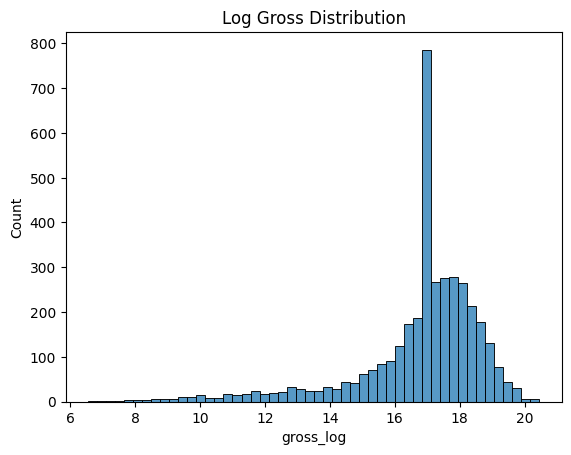

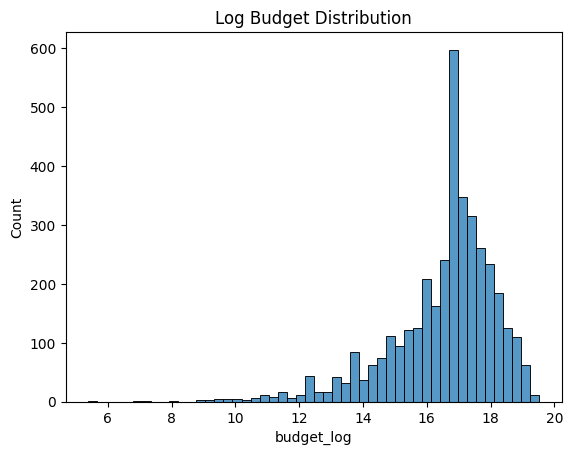

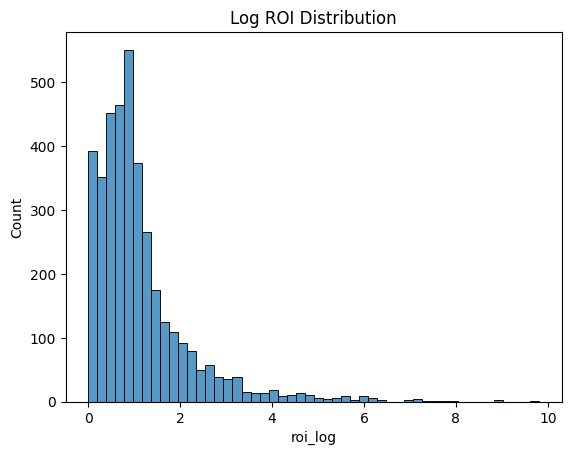

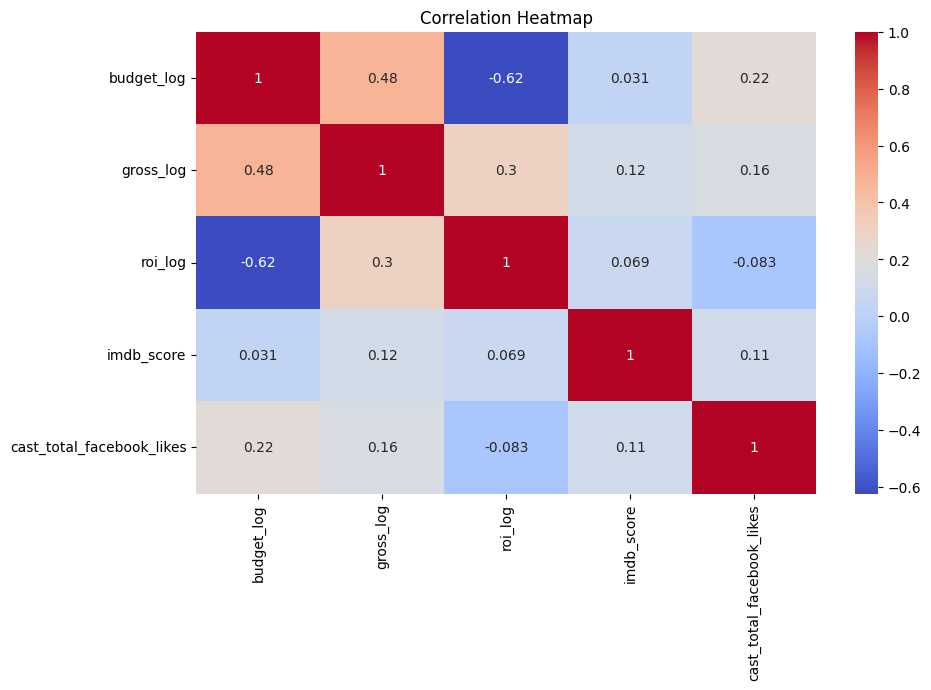

In [226]:
print("\nSummary statistics:")
print(df_selected.describe())

sns.histplot(df_selected['gross_log'], bins=50)
plt.title("Log Gross Distribution")
plt.show()

sns.histplot(df_selected['budget_log'], bins=50)
plt.title("Log Budget Distribution")
plt.show()

sns.histplot(df_selected['roi_log'], bins=50)
plt.title("Log ROI Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_selected[['budget_log','gross_log','roi_log','imdb_score','cast_total_facebook_likes']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Encode the categorical genre feature

In [227]:
# genres are seperated by | on the dataset
genre_dummies = df_selected['genres'].str.get_dummies(sep='|')

# Drop the original 'genres' column and concatenate the new dummy columns
df_encoded = pd.concat([df_selected.drop('genres', axis=1), genre_dummies], axis=1)

print(f"\nNumber of unique genres extracted: {genre_dummies.shape[1]}")


Number of unique genres extracted: 26


Scale all features

In [228]:
scaler = RobustScaler()
X = scaler.fit_transform(df_encoded)

K-Means hyperparameter tuning for number of clusters

In [229]:
print("\nK-Means Hyperparameter Tuning")

best_k = 0
best_score = -1

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    silhouette = silhouette_score(X, labels)
    sse = kmeans.inertia_
    db_index = davies_bouldin_score(X, labels)
    
    print(f"K={k} | Silhouette={silhouette:.3f} | SSE={sse:.2f} | DB={db_index:.3f}")
    
    if silhouette > best_score:
        best_score = silhouette
        best_k = k

print(f"\nBest K selected: {best_k}")


K-Means Hyperparameter Tuning
K=2 | Silhouette=0.254 | SSE=29404.90 | DB=1.487
K=3 | Silhouette=0.254 | SSE=24557.80 | DB=1.346
K=4 | Silhouette=0.258 | SSE=21250.40 | DB=1.303
K=5 | Silhouette=0.217 | SSE=18523.85 | DB=1.293
K=6 | Silhouette=0.182 | SSE=17381.27 | DB=1.366
K=7 | Silhouette=0.139 | SSE=16222.39 | DB=1.587
K=8 | Silhouette=0.136 | SSE=15370.22 | DB=1.579
K=9 | Silhouette=0.132 | SSE=14861.67 | DB=1.627
K=10 | Silhouette=0.126 | SSE=14402.35 | DB=1.666

Best K selected: 4


Final K-Means model after tuning

In [230]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X)

print("\nCluster sizes:")
print(df['cluster_kmeans'].value_counts())


Cluster sizes:
cluster_kmeans
1    2533
0     494
2     477
3     303
Name: count, dtype: int64


Let's visualize, using PCA to select 2 main dimensions

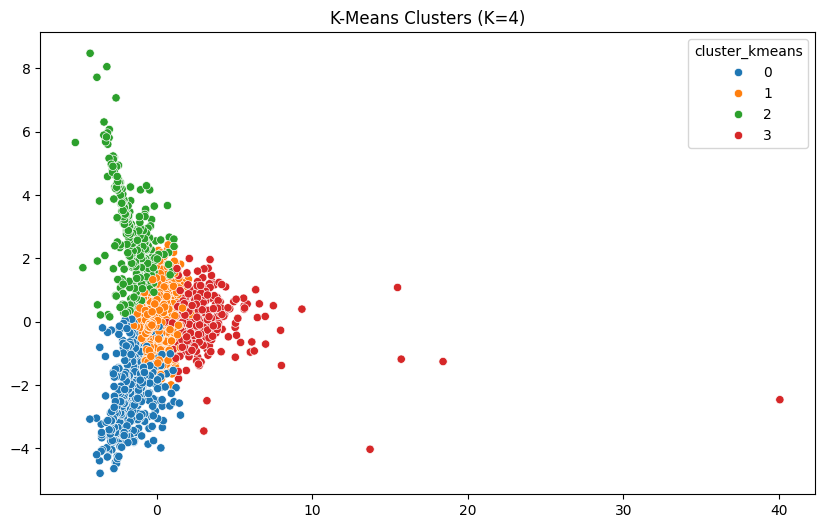

In [231]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                hue=df['cluster_kmeans'],
                palette='tab10')
plt.title(f"K-Means Clusters (K={best_k})")
plt.show()

Hierarchical Clustering

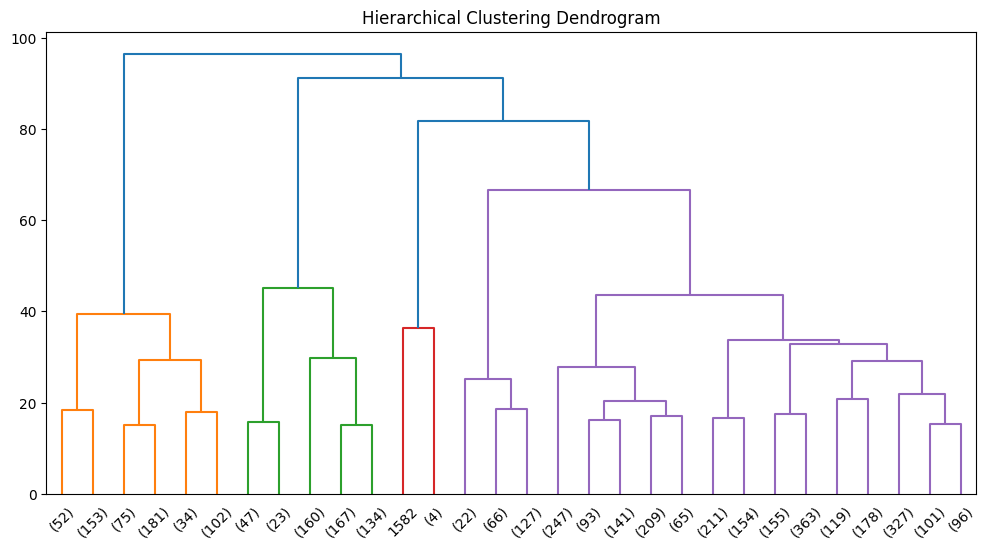

In [232]:
# use the best k found from tuning earlier
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['cluster_hc'] = hc.fit_predict(X)

linked = linkage(X, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

DBSCAN

In [233]:
db = DBSCAN(eps=1.5, min_samples=10)
df['cluster_dbscan'] = db.fit_predict(X)

n_clusters_db = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'] else 0)
print(f"\nDBSCAN clusters: {n_clusters_db}")


DBSCAN clusters: 3


Let's see the characteristics of each cluster

In [234]:
cluster_summary = df.groupby('cluster_kmeans')[
    ['budget','gross','roi','imdb_score','cast_total_facebook_likes','duration']
].mean()

genre_list = genre_dummies.columns.tolist()
df_encoded['cluster_kmeans'] = df['cluster_kmeans']
genre_means = df_encoded.groupby('cluster_kmeans')[genre_list].mean()

def get_top_genres(row, n=3):
    return row.nlargest(n).index.tolist()

top_genres_per_cluster = genre_means.apply(get_top_genres, axis=1)
cluster_summary['top_genres'] = top_genres_per_cluster

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
                      budget         gross         roi  imdb_score  \
cluster_kmeans                                                       
0               9.107689e+06  1.021372e+06    0.458515    6.305870   
1               4.113030e+07  5.582260e+07    1.775548    6.309554   
2               2.117767e+06  3.708183e+07  155.315037    6.442138   
3               7.173375e+07  1.109704e+08    2.202097    6.833993   

                cast_total_facebook_likes    duration  \
cluster_kmeans                                          
0                             5784.550607  100.374494   
1                             8226.958547  107.309120   
2                             3053.320755   99.226415   
3                            53827.141914  120.290429   

                               top_genres  
cluster_kmeans                             
0                [Drama, Comedy, Romance]  
1               [Drama, Comedy, Thriller]  
2                 [Drama, Comedy, Horror] 